# Import

In [1]:
!pip install keras_cv_attention_models

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.1/191.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.1/806.1 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00


In [2]:
# dir management lib
import os
import shutil
from sklearn.model_selection import train_test_split
import requests
import re
import random
import hashlib
from google.colab import drive
from numpy.random import shuffle

In [3]:
# data analys lib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [4]:
# Model shenenigans
from keras_cv_attention_models import efficientformer
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
from sklearn.utils import class_weight

[WARNING] Setting TF_USE_LEGACY_KERAS=1. Make sure this is ahead of importing tensorflow or keras.


In [5]:
def set_seeds(seed=67):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

&nbsp;

# Dataset Load

In [6]:
!unzip '/content/Dataset_Split.zip'

Archive:  /content/Dataset_Split.zip
  inflating: Dataset_Split/valid/hypertrophic/hqdefault.jpg  
  inflating: Dataset_Split/valid/hypertrophic/th - 2022-01-10T161455.422.jpg  
  inflating: Dataset_Split/valid/hypertrophic/th (74).jpg  
  inflating: Dataset_Split/valid/hypertrophic/th - 2022-01-10T174846.995.jpg  
  inflating: Dataset_Split/valid_lab/keloid/th - 2022-01-09T181129.480.jpg  
  inflating: Dataset_Split/valid/hypertrophic/th - 2022-01-10T170448.037.jpg  
  inflating: Dataset_Split/valid/hypertrophic/images - 2022-01-09T151021.683.jpg  
  inflating: Dataset_Split/valid/hypertrophic/th - 2022-01-10T161429.581.jpg  
  inflating: Dataset_Split/valid/hypertrophic/th - 2022-01-10T171819.077.jpg  
  inflating: Dataset_Split/valid/hypertrophic/th - 2022-01-10T160931.876.jpg  
  inflating: Dataset_Split/valid/hypertrophic/hypertrophic_5.jpg  
  inflating: Dataset_Split/valid_lab/hypertrophic/hypertrophic_5.jpg  
  inflating: Dataset_Split/valid/hypertrophic/th - 2022-01-10T163414.

In [7]:
saved_data_dir = '/content/Dataset_Split'

In [8]:
TRAIN_DIR, VAL_DIR, TEST_DIR = os.path.join(saved_data_dir, 'train'), os.path.join(saved_data_dir, 'valid'), os.path.join(saved_data_dir, 'test')

&nbsp;

# Datagen

In [56]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

def create_generators(train_p, val_p, test_p):
    tr = train_datagen.flow_from_directory(train_p, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True)
    vl = val_test_datagen.flow_from_directory(val_p, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)
    ts = val_test_datagen.flow_from_directory(test_p, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)
    return tr, vl, ts

# Standard Generators
print('Loading X1')
train_generator, val_generator, test_generator = create_generators(TRAIN_DIR, VAL_DIR, TEST_DIR)

Loading X1
Found 392 images belonging to 2 classes.
Found 86 images belonging to 2 classes.
Found 87 images belonging to 2 classes.


&nbsp;

# Model Trainin

### Callback Function

In [59]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=50,
    verbose=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=7,
    min_lr=1e-8,
    verbose=0
)

class ThresholdCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('val_accuracy') is not None and logs.get('val_accuracy') >= 0.90:
            print("\nReached 90% validation accuracy, stopping training!")
            self.model.stop_training = True

threshold_callback = ThresholdCallback()

callbacks_list = [
    early_stopping,
    reduce_lr,
    threshold_callback,
]

In [60]:
all_generators = [
    ("X1 Standard", train_generator),
]

all_class_weights = {}

print("Calculating class weights for standard versions...")
for name, gen in all_generators:
    labels = np.unique(gen.classes)
    weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=labels,
        y=gen.classes
    )
    all_class_weights[name] = dict(zip(labels, weights))
    print(f"{name}: {all_class_weights[name]}")

class_weights = all_class_weights["X1 Standard"]

Calculating class weights for standard versions...
X1 Standard: {np.int32(0): np.float64(1.5076923076923077), np.int32(1): np.float64(0.7480916030534351)}


In [61]:
NUM_CLASSES = 2
INPUT_SHAPE = (224, 224, 3)

&nbsp;

&nbsp;

## X1 Standard

In [67]:
base_model_ef = efficientformer.EfficientFormerL1(
    input_shape=INPUT_SHAPE,
    num_classes=0,
    pretrained='imagenet'
)
base_model_ef.trainable = True


efficientformer_transfer = models.Sequential([
    base_model_ef,
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, kernel_regularizer=regularizers.l2(0.05)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

efficientformer_transfer.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

>>>> Load pretrained from: /root/.keras/models/efficientformer_l1_224_imagenet.h5


In [68]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) found: {gpus}")
    history = efficientformer_transfer.fit(
        train_generator,
        epochs=150 if gpus else 50,
        validation_data=val_generator,
        callbacks=callbacks_list,
        class_weight=all_class_weights['X1 Standard'],
        verbose=1
    )

GPU(s) found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/150
13/13 [==============================] - 40s 529ms/step - loss: 10.5526 - accuracy: 0.4923 - val_loss: 12.5219 - val_accuracy: 0.3721 - lr: 1.0000e-04
Epoch 2/150
13/13 [==============================] - 6s 471ms/step - loss: 10.2003 - accuracy: 0.5255 - val_loss: 11.4091 - val_accuracy: 0.3605 - lr: 1.0000e-04
Epoch 3/150
13/13 [==============================] - 6s 460ms/step - loss: 9.8130 - accuracy: 0.6454 - val_loss: 10.2474 - val_accuracy: 0.4884 - lr: 1.0000e-04
Epoch 4/150
13/13 [==============================] - 7s 556ms/step - loss: 9.4551 - accuracy: 0.6531 - val_loss: 9.7460 - val_accuracy: 0.5116 - lr: 1.0000e-04
Epoch 5/150
13/13 [==============================] - 6s 458ms/step - loss: 9.1111 - accuracy: 0.6811 - val_loss: 9.2019 - val_accuracy: 0.6279 - lr: 1.0000e-04
Epoch 6/150
13/13 [==============================] - 7s 545ms/step - loss: 8.7693 - accuracy: 0.7474 - val_loss: 

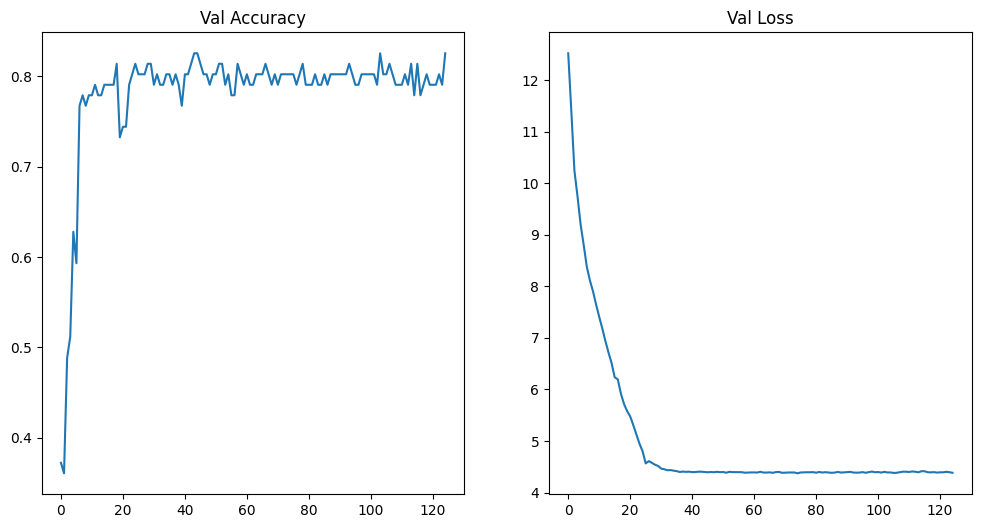

In [76]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Val Accuracy')
sns.lineplot(history.history['val_accuracy'])

plt.subplot(1, 2, 2)
plt.title('Val Loss')
sns.lineplot(history.history['val_loss'])

plt.show()

In [69]:
y_pred_probs = efficientformer_transfer.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report for X1 Standard:\n")
print(report)

3/3 [==============================] - 1s 85ms/step
Classification Report for X1 Standard:

              precision    recall  f1-score   support

hypertrophic       0.77      0.79      0.78        29
      keloid       0.89      0.88      0.89        58

    accuracy                           0.85        87
   macro avg       0.83      0.84      0.83        87
weighted avg       0.85      0.85      0.85        87



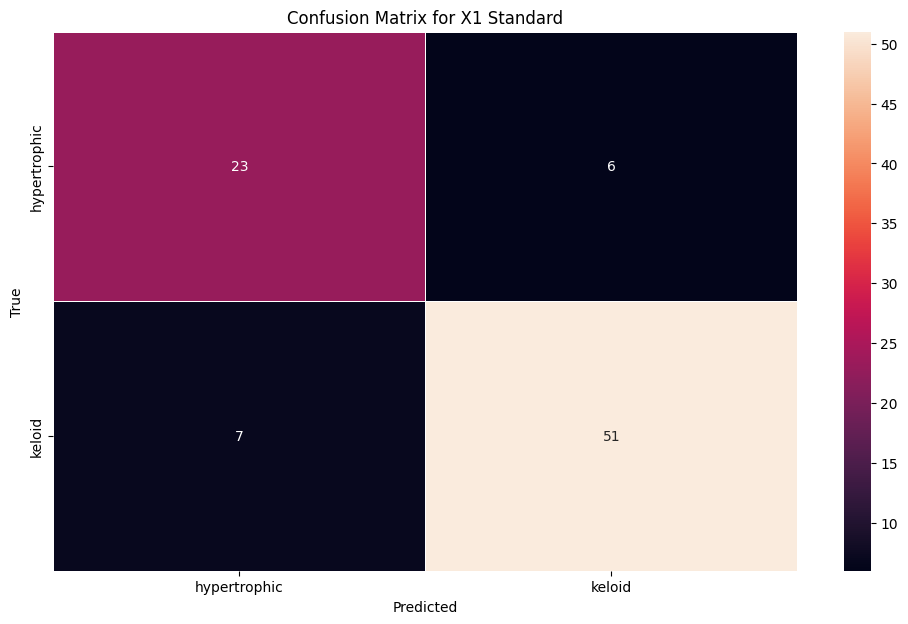

In [85]:
cf = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 7))
sns.heatmap(cf, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, linewidths=0.5)
plt.title('Confusion Matrix for X1 Standard')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

&nbsp;

# Saving dus Model

In [86]:
saved_model_dir = '/content/Saved_Model'
if not os.path.exists(saved_model_dir):
    os.makedirs(saved_model_dir)

tflite_model_path = os.path.join(saved_model_dir, 'efficientformer_model.tflite')

print("Converting model to TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(efficientformer_transfer)
tflite_model = converter.convert()

with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model successfully saved at: {tflite_model_path}")

Converting model to TFLite...
TFLite model successfully saved at: /content/Saved_Model/efficientformer_model.tflite


&nbsp;

# Testing Model
test the tflite file for making sure the model didnt get downgrade

In [87]:
print("Testing the model on the test dataset...")
test_loss, test_accuracy = efficientformer_transfer.evaluate(test_generator)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Testing the model on the test dataset...
3/3 [==============================] - 0s 93ms/step - loss: 4.2305 - accuracy: 0.8506

Test Loss: 4.2305
Test Accuracy: 0.8506


In [88]:
test_generator.reset()

print("Generating predictions...")
y_pred_probs = efficientformer_transfer.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print("Classification Report for Test Dataset:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

Generating predictions...
3/3 [==============================] - 0s 92ms/step
Classification Report for Test Dataset:

              precision    recall  f1-score   support

hypertrophic       0.77      0.79      0.78        29
      keloid       0.89      0.88      0.89        58

    accuracy                           0.85        87
   macro avg       0.83      0.84      0.83        87
weighted avg       0.85      0.85      0.85        87



&nbsp;

&nbsp;